Device: cpu


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]


GENERATED TEXT
------------------------------------------------------------
A recent study by the University of California, Berkeley, shows that artificial intelligence is a very useful tool for a wide variety of applications. It is a very useful tool for a wide variety of applications, including computer vision, speech recognition, and speech recognition. It is also a very useful tool for a wide variety of other applications, such as computer vision, speech recognition, speech recognition, and speech recognition. The study also shows that it is a very useful tool for a wide variety of other applications, such as computer vision, speech recognition, speech recognition, speech recognition, speech recognition, speech recognition, speech recognition, speech recognition, speech recognition, speech recognition, speech recognition, speech recognition, speech recognition, speech recognition, speech recognition, speech recognition, speech recognition, speech recognition, speech recognition, s

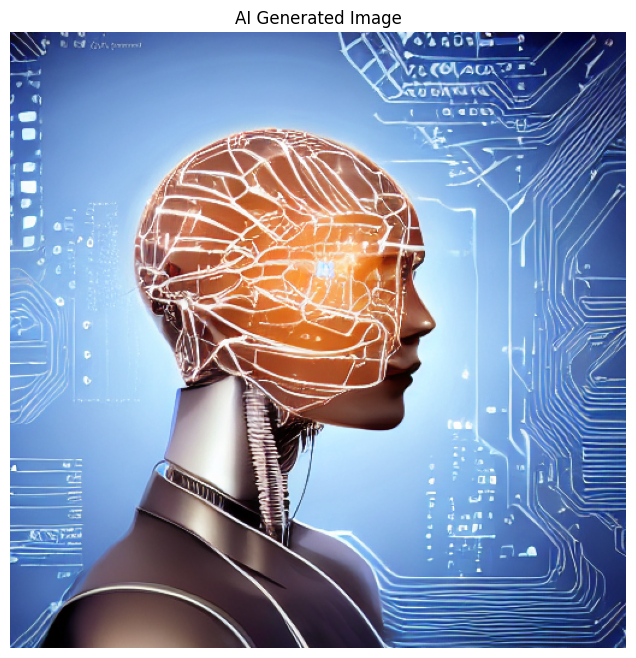


Image saved as generated_content_image.png


In [ ]:
!pip install transformers diffusers accelerate torch pillow matplotlib sentencepiece -q

import torch
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM
)

from diffusers import StableDiffusionPipeline


# 1. Set device

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)


# 2. Load pretrained text generation model

text_model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(
    text_model_name
)

text_model = AutoModelForSeq2SeqLM.from_pretrained(
    text_model_name
).to(device)


# 3. Function to generate text

def generate_text(prompt, max_tokens=180):

    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True
    ).to(device)

    outputs = text_model.generate(
        **inputs,
        max_new_tokens=max_tokens,
        do_sample=False
    )

    return tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )


# 4. Load pretrained image generation model

image_generator = StableDiffusionPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=(
        torch.float16
        if device == "cuda"
        else torch.float32
    )
)

image_generator = image_generator.to(device)


# 5. Get content topic

topic = input("Enter a content topic: ")


# 6. Generate text content

text_prompt = f"""
Write a short article of about 120 words on the topic:
{topic}

Include:

1. Introduction
2. Importance
3. Applications

Use simple language.
"""

generated_text = generate_text(
    text_prompt,
    max_tokens=180
)


# 7. Generate image

image_prompt = f"""
A realistic high-quality illustration representing
{topic},
professional digital art,
highly detailed,
4K quality
"""

generated_image = image_generator(
    image_prompt
).images[0]


# 8. Save generated image

generated_image.save(
    "generated_content_image.png"
)


# 9. Display generated text

print("\nGENERATED TEXT")
print("-" * 60)

print(generated_text)


# 10. Display generated image

plt.figure(figsize=(8, 8))

plt.imshow(generated_image)

plt.axis("off")

plt.title("AI Generated Image")

plt.show()


# 11. Display saved image message

print(
    "\nImage saved as generated_content_image.png"
)